# Smolyak Polynomial Interpolation Demo

This notebook illustrates the behavior of `SmolyakPolyInterp` on a collection of highly nonlinear 2D functions. For each example, it fits a sparse-grid Chebyshev interpolant and shows:

1. True surface vs. interpolant surface, with sparse-grid nodes overlaid.
2. A filled contour plot of approximation errors.
3. Analytical Jacobian vs. interpolant Jacobian, with one subplot per component.
4. Analytical Hessian vs. interpolant Hessian, with one subplot per Hessian entry.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

import smolyakpoly as slp

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=5, suppress=True)


In [2]:
@dataclass
class Example2D:
    name: str
    func: Callable[[np.ndarray], float]
    grad: Callable[[np.ndarray], np.ndarray]
    hess: Callable[[np.ndarray], np.ndarray]
    lb: tuple[float, float]
    ub: tuple[float, float]
    levels: tuple[int, int]
    accuracy: int


def sample_domain(lb, ub, n_side=81):
    x0 = np.linspace(lb[0], ub[0], n_side)
    x1 = np.linspace(lb[1], ub[1], n_side)
    X0, X1 = np.meshgrid(x0, x1, indexing='xy')
    X = np.column_stack([X0.ravel(), X1.ravel()])
    return X0, X1, X


def eval_true(func, points):
    return np.asarray([func(p) for p in points], dtype=float)


def eval_grad(grad, points):
    return np.asarray([grad(p) for p in points], dtype=float)


def eval_hess(hess, points):
    return np.asarray([hess(p) for p in points], dtype=float)


def add_reference_line(ax, x, y):
    lo = min(np.min(x), np.min(y))
    hi = max(np.max(x), np.max(y))
    pad = 0.05 * max(hi - lo, 1.0)
    lo -= pad
    hi += pad
    ax.plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=1.0)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)


def plot_example(example: Example2D, n_surface=81, n_scatter=1000, seed=123):
    interp = slp.SmolyakPolyInterp(
        levels=example.levels,
        lb=example.lb,
        ub=example.ub,
        accuracy=example.accuracy,
        showtrace=False,
    )
    interp.fit(example.func)

    X0, X1, X = sample_domain(example.lb, example.ub, n_side=n_surface)
    true_vals = eval_true(example.func, X).reshape(X0.shape)
    pred_vals = interp(X).reshape(X0.shape)
    err_vals = pred_vals - true_vals

    rng = np.random.default_rng(seed)
    pts = rng.uniform(np.asarray(example.lb), np.asarray(example.ub), size=(n_scatter, 2))
    true_grad = eval_grad(example.grad, pts)
    pred_grad = interp.jacobian(pts)
    true_hess = eval_hess(example.hess, pts)
    pred_hess = np.moveaxis(interp.hessian(pts), -1, 0)

    print(f'Example: {example.name}')
    interp.summary()
    print('Max abs interpolation error on surface grid:', np.max(np.abs(err_vals)))
    print('RMSE on surface grid:', np.sqrt(np.mean(err_vals ** 2)))

    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X0, X1, true_vals, color='lightgrey', alpha=0.65, linewidth=0, antialiased=True)
    ax.plot_surface(X0, X1, pred_vals, color='royalblue', alpha=0.55, linewidth=0, antialiased=True)
    node_z = interp(interp.grid)
    ax.scatter(interp.grid[:, 0], interp.grid[:, 1], node_z, color='crimson', s=18, depthshade=False)
    ax.set_title(f'{example.name}: true surface vs interpolant')
    ax.set_xlabel('x0')
    ax.set_ylabel('x1')
    ax.set_zlabel('f(x)')
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 6))
    contour = ax.contourf(X0, X1, err_vals, levels=30, cmap='coolwarm')
    ax.scatter(interp.grid[:, 0], interp.grid[:, 1], s=12, color='black', alpha=0.7)
    ax.set_title(f'{example.name}: interpolation error')
    ax.set_xlabel('x0')
    ax.set_ylabel('x1')
    fig.colorbar(contour, ax=ax, label='Interpolant - truth')
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for j in range(2):
        axes[j].scatter(true_grad[:, j], pred_grad[:, j], s=14, alpha=0.55, color='royalblue')
        add_reference_line(axes[j], true_grad[:, j], pred_grad[:, j])
        axes[j].set_title(f'{example.name}: Jacobian component {j}')
        axes[j].set_xlabel('Analytical')
        axes[j].set_ylabel('Interpolant')
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    for i in range(2):
        for j in range(2):
            ax = axes[i, j]
            ax.scatter(true_hess[:, i, j], pred_hess[:, i, j], s=14, alpha=0.55, color='darkorange')
            add_reference_line(ax, true_hess[:, i, j], pred_hess[:, i, j])
            ax.set_title(f'{example.name}: Hessian ({i}, {j})')
            ax.set_xlabel('Analytical')
            ax.set_ylabel('Interpolant')
    plt.tight_layout()
    plt.show()

    return interp


In [3]:
examples = [
    Example2D(
        name='Trigonometric mix',
        func=lambda x: np.sin(x[0]) + np.cos(x[1]),
        grad=lambda x: np.array([np.cos(x[0]), -np.sin(x[1])], dtype=float),
        hess=lambda x: np.array([
            [-np.sin(x[0]), 0.0],
            [0.0, -np.cos(x[1])],
        ], dtype=float),
        lb=(-3.0, -2.5),
        ub=(3.0, 2.5),
        levels=(6, 6),
        accuracy=5,
    ),
    Example2D(
        name='Coupled oscillation',
        func=lambda x: np.sin(1.8 * x[0] * x[1]) + 0.3 * np.cos(2.2 * x[0] - 0.7 * x[1]),
        grad=lambda x: np.array([
            1.8 * x[1] * np.cos(1.8 * x[0] * x[1]) - 0.66 * np.sin(2.2 * x[0] - 0.7 * x[1]),
            1.8 * x[0] * np.cos(1.8 * x[0] * x[1]) + 0.21 * np.sin(2.2 * x[0] - 0.7 * x[1]),
        ], dtype=float),
        hess=lambda x: np.array([
            [-(1.8 * x[1]) ** 2 * np.sin(1.8 * x[0] * x[1]) - 1.452 * np.cos(2.2 * x[0] - 0.7 * x[1]),
             1.8 * np.cos(1.8 * x[0] * x[1]) - 3.24 * x[0] * x[1] * np.sin(1.8 * x[0] * x[1]) + 0.462 * np.cos(2.2 * x[0] - 0.7 * x[1])],
            [1.8 * np.cos(1.8 * x[0] * x[1]) - 3.24 * x[0] * x[1] * np.sin(1.8 * x[0] * x[1]) + 0.462 * np.cos(2.2 * x[0] - 0.7 * x[1]),
             -(1.8 * x[0]) ** 2 * np.sin(1.8 * x[0] * x[1]) - 0.147 * np.cos(2.2 * x[0] - 0.7 * x[1])],
        ], dtype=float),
        lb=(-1.5, -1.5),
        ub=(1.5, 1.5),
        levels=(7, 7),
        accuracy=6,
    ),
    Example2D(
        name='Sharp nonlinear ridge',
        func=lambda x: np.exp(0.35 * x[0]) * np.sin(2.4 * x[1]) + 0.15 * x[0] ** 3 - 0.2 * x[0] * x[1],
        grad=lambda x: np.array([
            0.35 * np.exp(0.35 * x[0]) * np.sin(2.4 * x[1]) + 0.45 * x[0] ** 2 - 0.2 * x[1],
            2.4 * np.exp(0.35 * x[0]) * np.cos(2.4 * x[1]) - 0.2 * x[0],
        ], dtype=float),
        hess=lambda x: np.array([
            [0.1225 * np.exp(0.35 * x[0]) * np.sin(2.4 * x[1]) + 0.9 * x[0],
             0.84 * np.exp(0.35 * x[0]) * np.cos(2.4 * x[1]) - 0.2],
            [0.84 * np.exp(0.35 * x[0]) * np.cos(2.4 * x[1]) - 0.2,
             -5.76 * np.exp(0.35 * x[0]) * np.sin(2.4 * x[1])],
        ], dtype=float),
        lb=(-2.0, -1.0),
        ub=(2.0, 1.2),
        levels=(7, 7),
        accuracy=6,
    ),
]

len(examples)


3

Example: Trigonometric mix
SmolyakPolyInterp summary
  dim: 2
  levels: (6, 6)
  accuracy: 5
  n_multi_indices: 21
  n_nodes: 145
  n_basis: 145
  lb: (-3.0, -2.5)
  ub: (3.0, 2.5)
  fitted: True
Max abs interpolation error on surface grid: 1.609823385706477e-15
RMSE on surface grid: 4.3221594934767636e-16


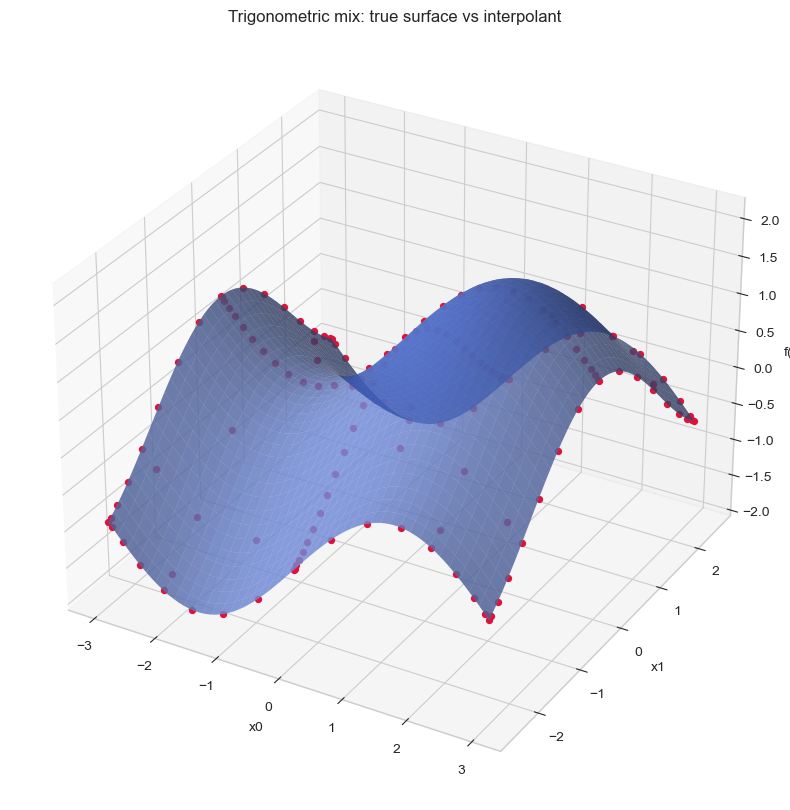

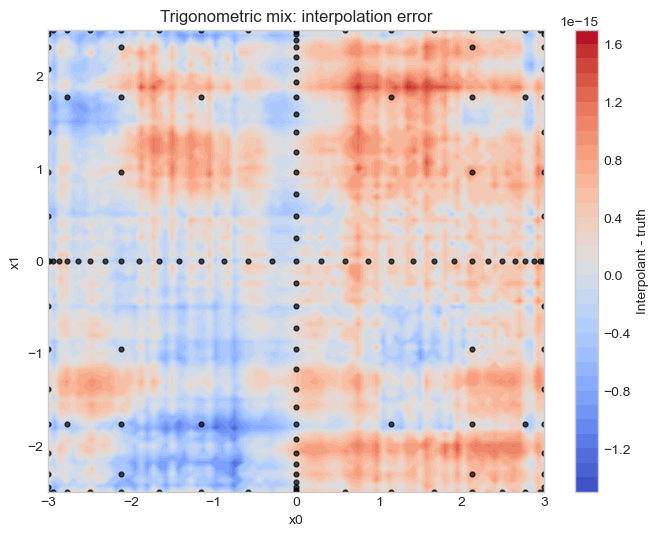

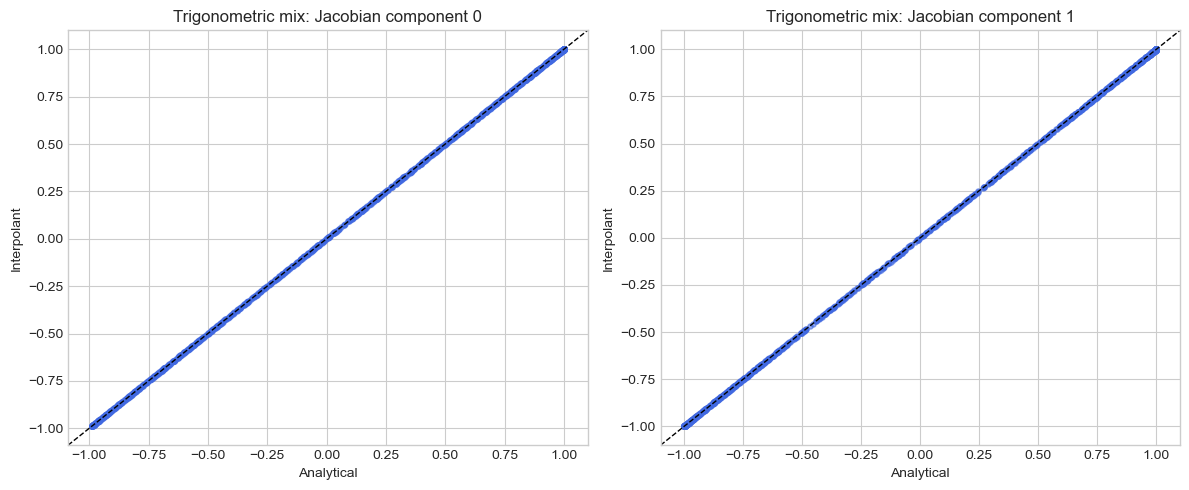

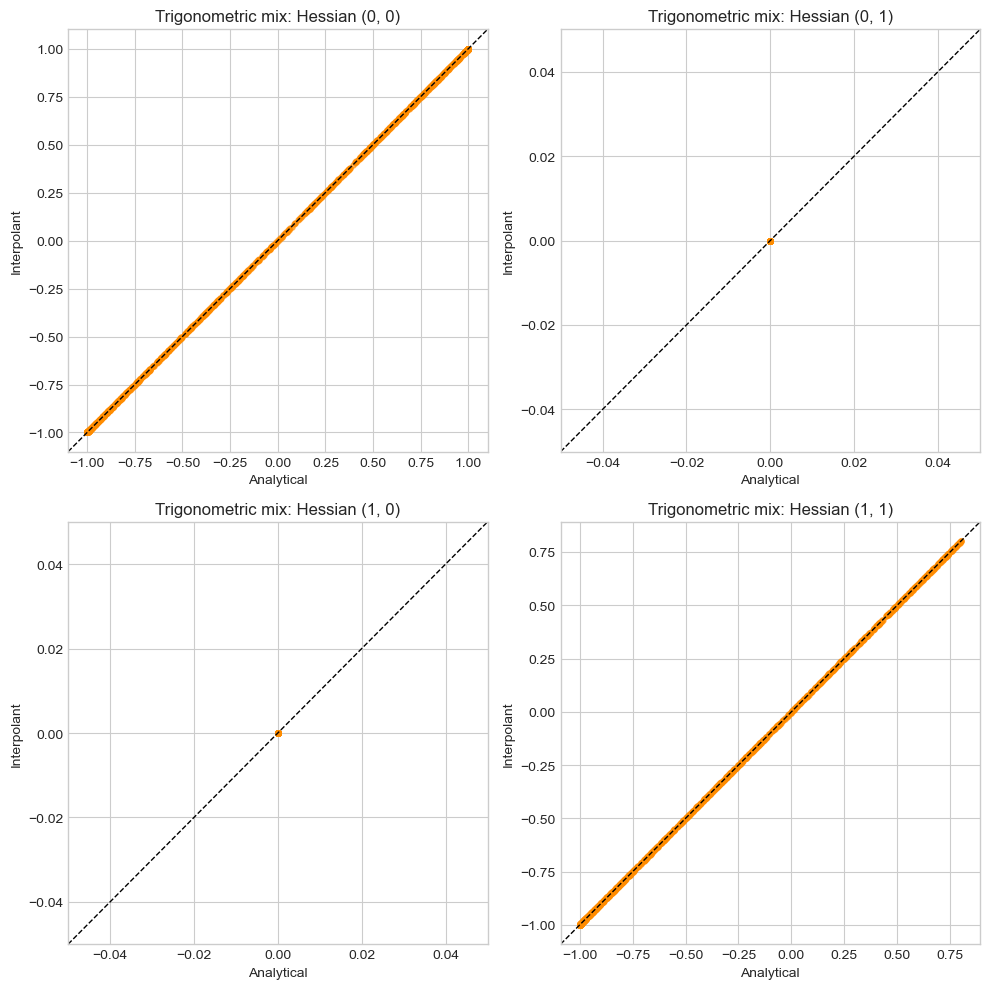

Example: Coupled oscillation
SmolyakPolyInterp summary
  dim: 2
  levels: (7, 7)
  accuracy: 6
  n_multi_indices: 28
  n_nodes: 321
  n_basis: 321
  lb: (-1.5, -1.5)
  ub: (1.5, 1.5)
  fitted: True
Max abs interpolation error on surface grid: 0.0013653075941232329
RMSE on surface grid: 0.0004948663815380303


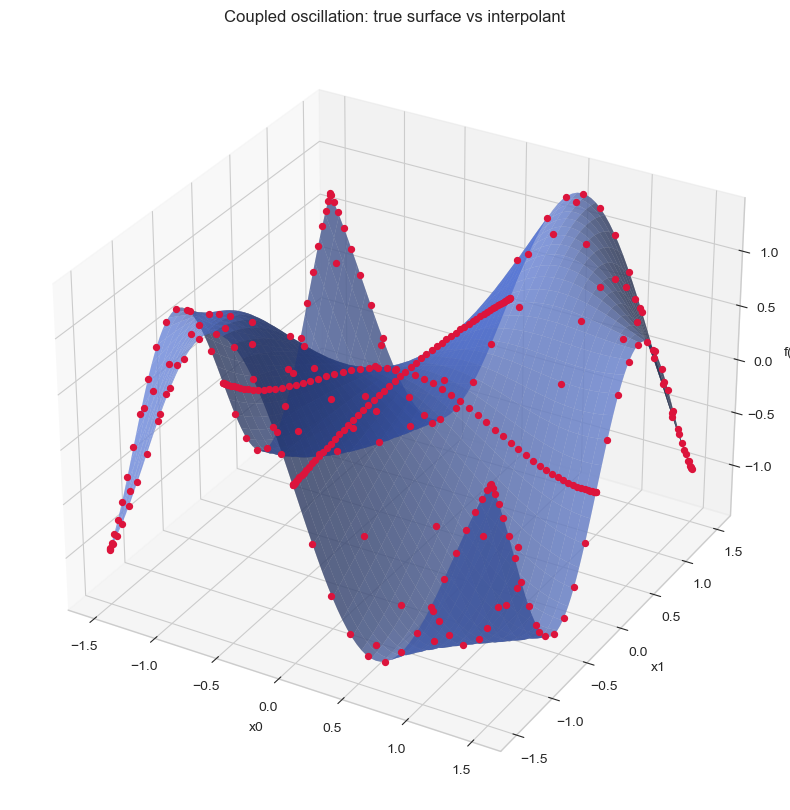

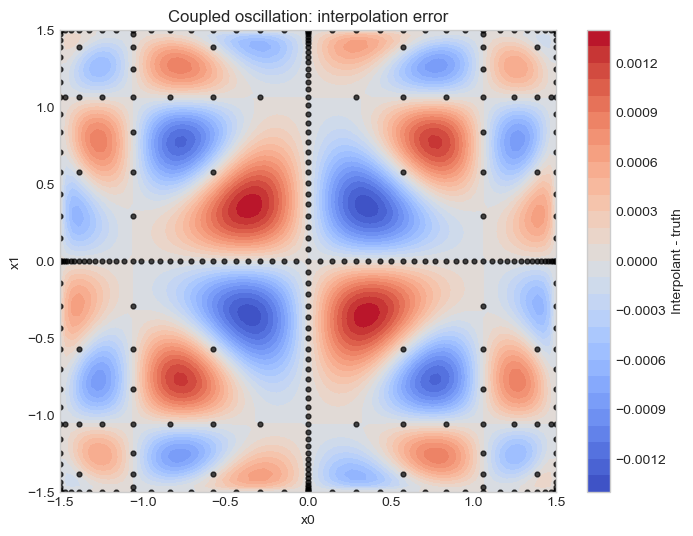

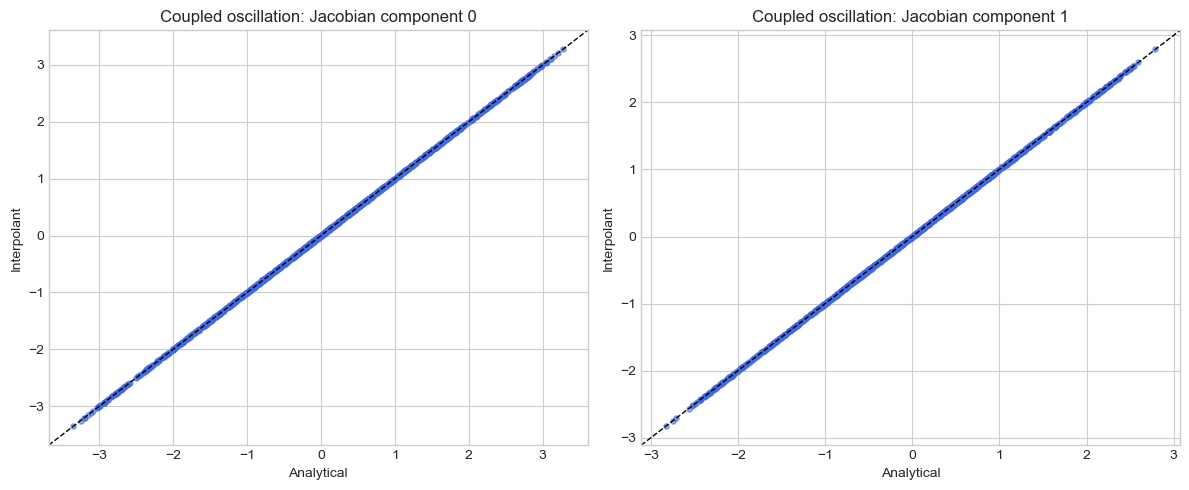

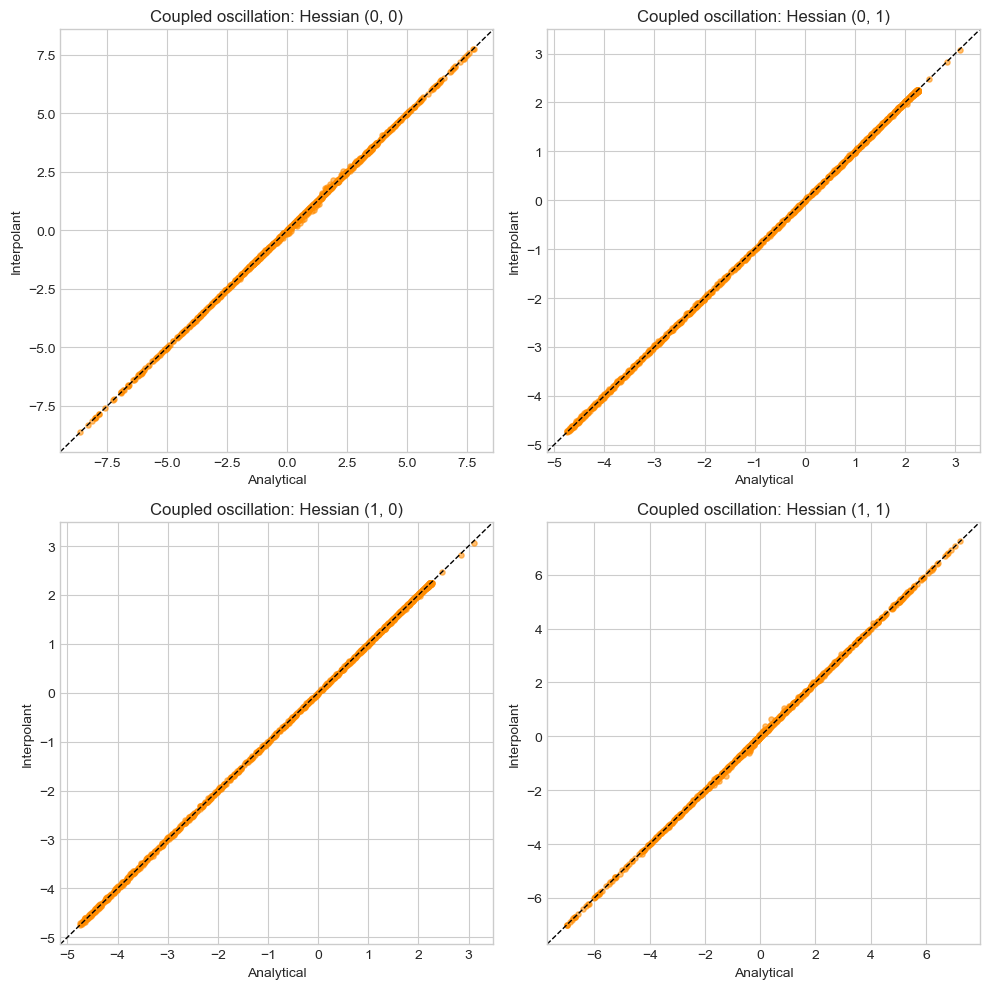

Example: Sharp nonlinear ridge
SmolyakPolyInterp summary
  dim: 2
  levels: (7, 7)
  accuracy: 6
  n_multi_indices: 28
  n_nodes: 321
  n_basis: 321
  lb: (-2.0, -1.0)
  ub: (2.0, 1.2)
  fitted: True
Max abs interpolation error on surface grid: 1.8966873793768713e-08
RMSE on surface grid: 6.448590017731609e-09


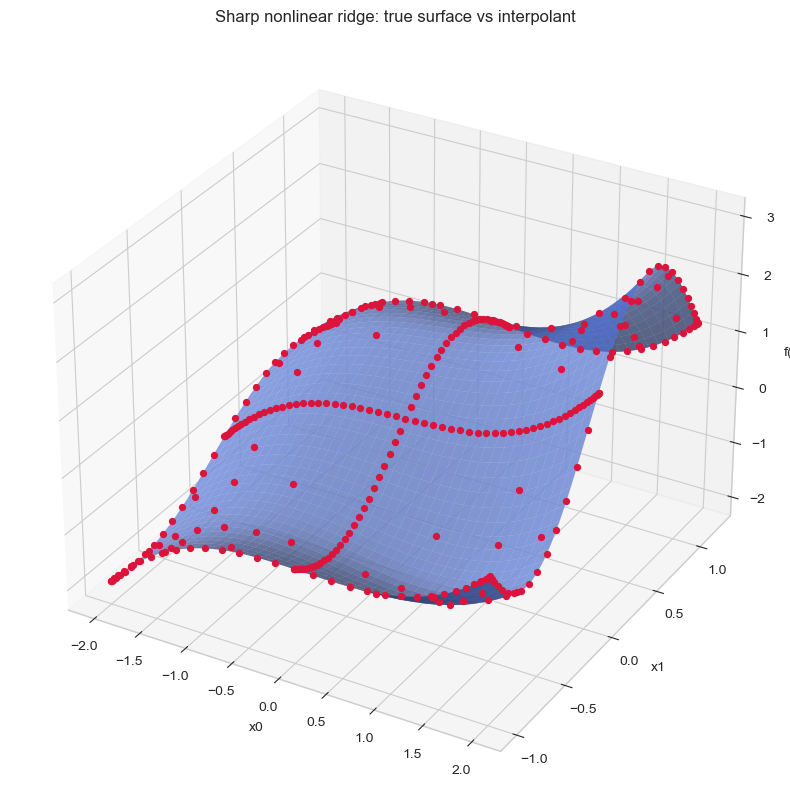

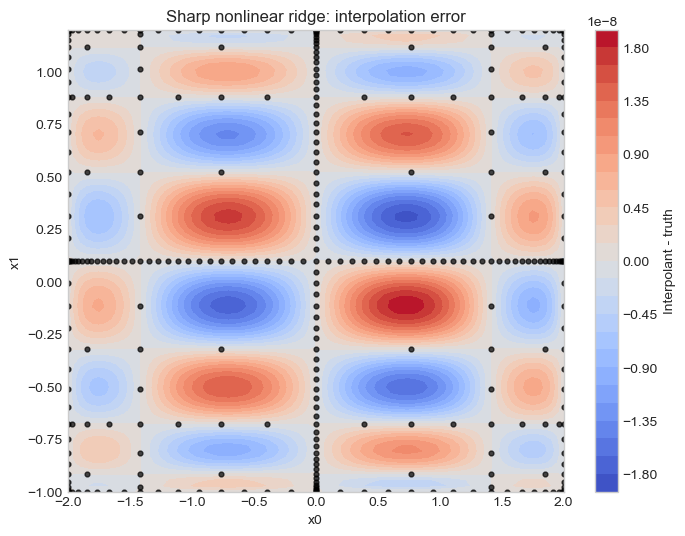

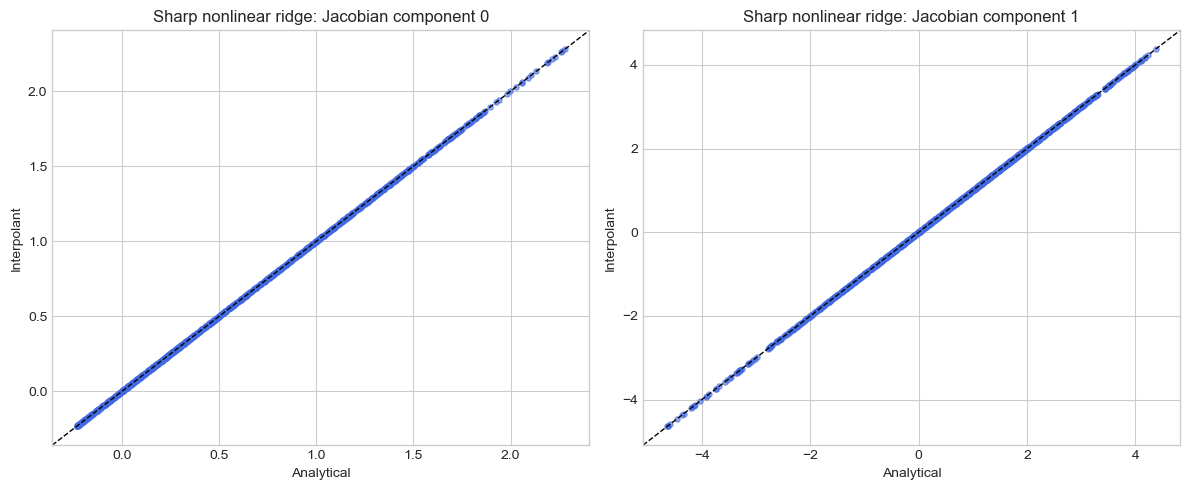

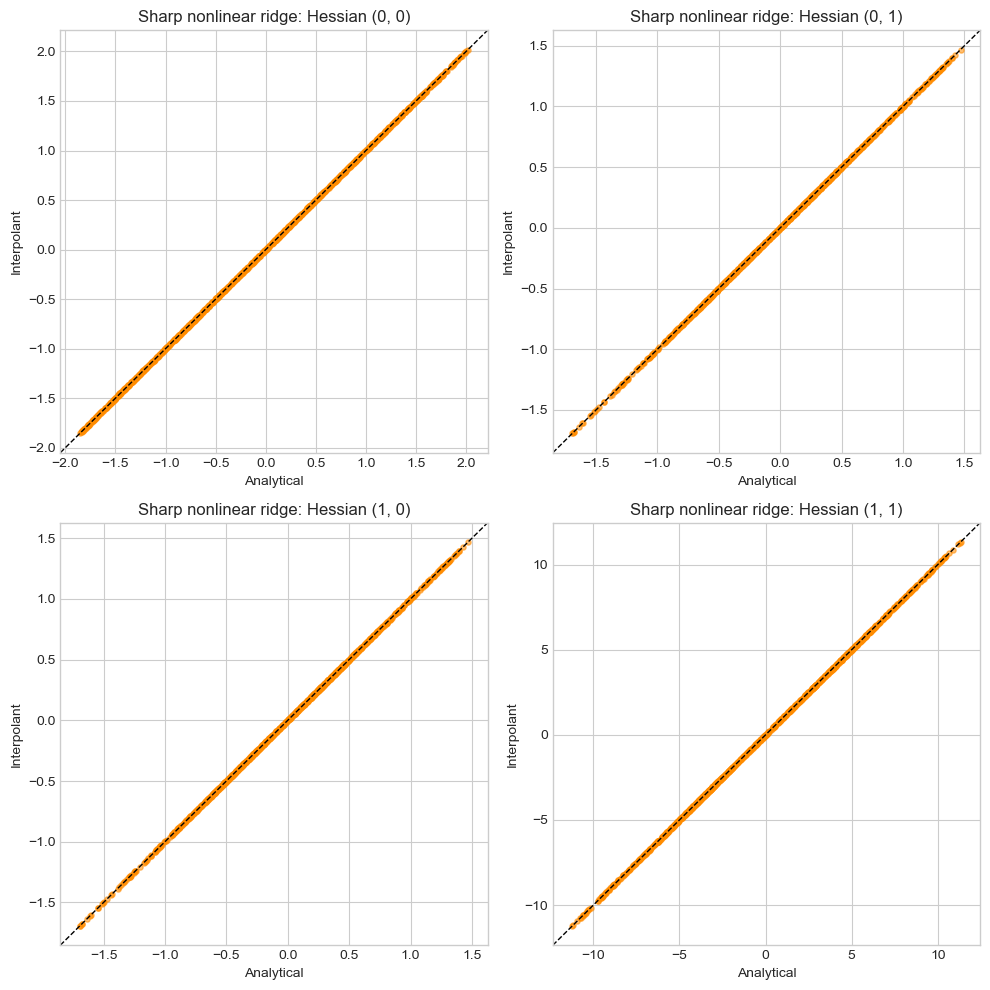

In [4]:
models = []
for example in examples:
    models.append(plot_example(example, n_surface=81, n_scatter=1200, seed=123))
